<a href="https://colab.research.google.com/github/AdsonFialho/MVP_Machine_Learning_Analytics/blob/main/MVP_Machine_Learning_Analytics_(4052025002646).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _Adson Fialho Marques_  
**Matrícula:** _4052025002646_  
**Data:** _05/07/2026_  
**Dataset:** _[Wholesale customers](https://archive.ics.uci.edu/dataset/292/wholesale+customers)_  
**Tipo de problema:** _Clusterização_  

**Sprint:** _Machine Learning & Analytics (40530010056_20260_01)_

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☑ |
| Dataset descrito, com fonte, atributos e restrições | ☑ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☑ |
| Análise exploratória objetiva, conectada à modelagem | ☑ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☑ |
| Prevenção de vazamento de dados | ☑ |
| Tratamentos de dados justificados | ☑ |
| Pipeline ou sequência reprodutível de pré-processamento | ☑ |
| Modelo baseline definido | ☑ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☑ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☑ |
| Avaliação com métricas coerentes com o problema | ☑ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☑ |
| Código limpo, organizado e executável do início ao fim | ☑ |
| Conclusão conectada ao objetivo inicial | ☑ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por
> se tratar de clusterização, dois itens foram atendidos de forma adaptada: não há
> divisão treino/teste tradicional (a justificativa está na Seção 5.1, pois o problema
> é descritivo e não preditivo), e a discussão de overfitting/underfitting aparece de
> forma contextualizada (Seção 10.1), já que esses conceitos se aplicam de modo limitado
> a modelos não supervisionados.


# 1. Definição do problema

## 1.1 Descrição do problema

Um distribuidor atacadista atende diversos clientes que compram produtos de
diferentes categorias ao longo do ano. Cada cliente tem um padrão de consumo
próprio: alguns gastam mais com produtos frescos, outros com mercearia, outros
com itens congelados, e assim por diante. Hoje, esses clientes são tratados de
forma parecida, sem uma separação clara entre os diferentes perfis de compra.

O problema que queremos resolver é justamente esse: **identificar grupos de
clientes com comportamentos de compra semelhantes**. Em vez de prever um valor
ou uma categoria já conhecida, a ideia é agrupar os clientes de acordo com a
semelhança entre seus gastos, revelando perfis que não estão rotulados nos dados.

Essa solução apoia principalmente **decisões de marketing e de operação** do
distribuidor. Sabendo quais perfis de cliente existem, a empresa pode direcionar
campanhas, ajustar o mix de produtos, planejar estoque e definir estratégias de
atendimento específicas para cada grupo, em vez de uma abordagem única para todos.

Os interessados diretos nessa análise seriam as **áreas de marketing, vendas e
gestão comercial** do distribuidor — pessoas que precisam entender melhor a base
de clientes para tomar decisões mais bem fundamentadas.

O problema é relevante porque conhecer o perfil dos clientes é um passo importante
para aumentar a eficiência das ações comerciais: campanhas mais certeiras, menos
desperdício de recursos e um atendimento mais adequado às necessidades reais de
cada tipo de cliente.


## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> O objetivo deste MVP é construir e avaliar modelos de clusterização para
> identificar perfis de clientes a partir de seus gastos anuais em diferentes
> categorias de produtos, comparando uma abordagem baseline com modelos
> candidatos e discutindo suas limitações.

## 1.3 Tipo de problema

**Tipo escolhido:** Clusterização (aprendizado não-supervisionado)

**Justificativa:**

O objetivo é agrupar clientes com padrões de gasto semelhantes, e não prever um
valor ou uma categoria previamente conhecida. Isso descarta os demais tipos de
problema: não é classificação, porque não temos uma classe-alvo que queremos
prever; não é regressão, porque não há um valor numérico contínuo a ser estimado;
e não é série temporal, porque os dados são um retrato dos gastos anuais de cada
cliente, sem uma dimensão de tempo a ser respeitada.

O que temos são clientes descritos por seus gastos em seis categorias de produtos,
sem nenhum rótulo indicando a que grupo cada um pertence. A tarefa é justamente
**descobrir** esses grupos a partir da semelhança entre os clientes — que é
exatamente o que caracteriza um problema de clusterização.

Vale registrar que o dataset possui uma coluna categórica (Channel) que poderia
funcionar como rótulo. No entanto, ela não será usada para formar os grupos: o
modelo trabalhará apenas com as variáveis de gasto. Essa coluna será reservada
para uma etapa posterior de avaliação, servindo como referência externa para
verificar se os grupos encontrados fazem sentido.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Existem perfis distintos de clientes na base, ou seja, os padrões de gasto
   não são homogêneos e podem ser separados em grupos com características próprias.
2. As variáveis de gasto possuem escalas muito diferentes e forte assimetria, de
   modo que será necessário transformar e padronizar os dados antes da modelagem
   para que a medida de distância entre clientes não seja dominada por poucas
   categorias de valor mais alto.
3. Os grupos encontrados apenas a partir do comportamento de gasto terão alguma
   relação com o tipo de cliente (Channel), indicando que os clusters capturam
   uma estrutura real e não apenas ruído.

**Critérios de sucesso:**

- **Métrica principal:** silhouette score, que mede simultaneamente a coesão
  interna e a separação entre os grupos, sem depender de rótulos. Como métrica
  de apoio, também será observado o índice Davies-Bouldin.
- **Resultado esperado:** obter uma configuração de agrupamento com silhouette
  positivo e consistente, que represente uma separação real dos clientes, e não
  uma divisão arbitrária. Os modelos candidatos (DBSCAN e clusterização
  hierárquica) serão comparados ao baseline (K-Means) de forma justa, usando as
  mesmas métricas.
- **Restrição prática:** priorizar a interpretabilidade dos grupos. Mais do que
  obter o maior silhouette possível, o resultado precisa gerar perfis de cliente
  que façam sentido para o negócio e possam ser descritos de forma clara.


# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [1]:
# Biblioteca para Warnings
import warnings

# Bibliotecas para manipulação e análise de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import StandardScaler

# Modelos de clusterização
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Métricas de avaliação para clusterização
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Fixamos uma seed única e reutilizável em todo o notebook.
# Isso garante que resultados que dependem de aleatoriedade (como a
# inicialização dos centroides do K-Means) sejam sempre os mesmos a cada execução.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Ajustes visuais para deixar os gráficos mais legíveis ao longo do notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Suprimindo warnings gerados por bibliotecas para uma saída mais limpa
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [2]:
# Registramos as versões das principais bibliotecas usadas, para fins de
# reprodutibilidade. Assim, quem for executar este notebook sabe em qual
# ambiente ele foi desenvolvido e testado.
import sklearn

print("Versões das bibliotecas utilizadas:")
print(f"  pandas       : {pd.__version__}")
print(f"  numpy        : {np.__version__}")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  seaborn      : {sns.__version__}")

Versões das bibliotecas utilizadas:
  pandas       : 2.2.2
  numpy        : 2.0.2
  scikit-learn : 1.6.1
  seaborn      : 0.13.2


## 2.1 Dependências adicionais

Não há dependências adicionais a instalar. Todas as bibliotecas utilizadas neste
MVP (pandas, numpy, matplotlib, seaborn e scikit-learn) já fazem parte do ambiente
padrão do Google Colab. Optou-se por manter o projeto enxuto, sem instalar pacotes
externos, justamente para reduzir o risco de falhas na execução durante a correção.

## 2.2 Funções auxiliares

Ao longo deste notebook, algumas rotinas se repetem — em especial o cálculo das métricas
de avaliação dos agrupamentos. Para evitar repetição de código, essas rotinas foram
reunidas em funções auxiliares.

Optou-se por **definir cada função no ponto em que ela é usada pela primeira vez**, e não
antecipadamente nesta seção. A razão é que as necessidades de código só ficam claras ao
longo do desenvolvimento: definir as funções aqui, antes mesmo de conhecer os detalhes da
modelagem, tornaria o código menos natural de acompanhar.

---
> **Nota de revisão:** esta seção foi revisada após a conclusão do projeto. As funções
> auxiliares mencionadas (`evaluate`, na Seção 8, e `metrics_row`, na Seção 11) foram
> identificadas e organizadas durante o desenvolvimento, e este registro foi atualizado
> para refletir onde elas se encontram.

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

**Dataset:** Wholesale customers

**Fonte:** UCI Machine Learning Repository
(https://archive.ics.uci.edu/dataset/292/wholesale+customers)

Para garantir que o notebook seja executado do início ao fim sem upload manual,
o arquivo original foi hospedado em um repositório público no GitHub e é carregado
diretamente por sua URL (formato *raw*), conforme exigido pelas instruções do MVP.

**Por que este dataset foi escolhido:**

O Wholesale customers descreve clientes reais de um distribuidor atacadista por
meio de seus gastos anuais em diferentes categorias de produtos. Ele foi escolhido
por três motivos principais. Primeiro, é um conjunto de dados clássico e bastante
adequado para problemas de clusterização, já que reúne clientes com perfis de
consumo variados, sem um rótulo pré-definido de grupo. Segundo, possui um tamanho
e uma quantidade de variáveis que permitem uma análise clara e interpretável, sem
exigir grande custo computacional. Terceiro, ele não foi utilizado em nenhuma das
aulas da sprint, atendendo à exigência de usar uma base nova.

**Restrições e condições consideradas:**

O dataset foi verificado quanto à sua adequação ao problema: contém apenas variáveis
numéricas de gasto e duas variáveis categóricas de contexto (Channel e Region), sem
identificadores pessoais dos clientes. Não há, portanto, questões de privacidade ou
de dados sensíveis envolvidas.

**Licença:**

O conjunto de dados é disponibilizado sob a licença Creative Commons Attribution 4.0
International (CC BY 4.0), que permite o uso e a adaptação para qualquer finalidade,
inclusive acadêmica, desde que a devida atribuição seja feita à fonte original.


## 3.2 Carga dos dados


In [3]:
# A base é carregada diretamente a partir de uma URL pública (arquivo raw no GitHub).
DATA_URL = "https://raw.githubusercontent.com/AdsonFialho/MVP_Machine_Learning_Analytics/refs/heads/main/Wholesale_customers_dataset.csv"

# O read_csv aceita uma URL diretamente, então o pandas baixa e lê o arquivo na hora.
df = pd.read_csv(DATA_URL)

# Visualizamos as primeiras linhas apenas para confirmar que a carga ocorreu bem.
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 3.3 Visão geral do dataset



In [4]:
# Dimensões da base: quantas linhas (clientes) e colunas (atributos) temos.
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

# Tipos de cada atributo. Aqui confirmamos se as variáveis vieram como numéricas.
print("Tipos dos atributos:")
print(df.dtypes)

O dataset possui 440 linhas e 8 colunas.

Tipos dos atributos:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


In [5]:
# Verificação de valores ausentes em cada coluna.
# Em clusterização, valores ausentes são um problema porque o cálculo de
# distância entre os pontos não lida bem com lacunas.
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print(f"\nTotal de valores ausentes: {df.isnull().sum().sum()}")

Valores ausentes por coluna:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Total de valores ausentes: 0


In [6]:
# Verificação de linhas duplicadas. Clientes com exatamente os mesmos gastos
# em todas as categorias poderiam enviesar a formação dos grupos.
print(f"Número de linhas duplicadas: {df.duplicated().sum()}")

Número de linhas duplicadas: 0


> **Observações da visão geral**
> - **Dimensões:** a base tem 440 registros (clientes) e 8 colunas.
> - **Tipos:** todas as colunas são numéricas (inteiros). As seis variáveis de
>  gasto (Fresh, Milk, Grocery, Frozen, Detergents_Paper e Delicassen) são contínuas. As colunas Channel e Region, embora estejam representadas por números, são na verdade **categóricas** — os números são apenas códigos.
> - **Valores ausentes:** não há valores ausentes, o que dispensa etapas de imputação.
> - **Duplicatas:** não há linhas duplicadas.
> - **Target:** por se tratar de um problema não-supervisionado, não há uma variável target a ser prevista. O agrupamento é construído apenas a partir das semelhanças entre os gastos dos clientes.

## 3.4 Dicionário de dados

Preencha a tabela abaixo com os principais atributos.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Channel | categórica | _Cliente: 1 = Horeca (hotéis/restaurantes/cafés), 2 = Retail (varejo)_ | não | _Reservada como rótulo externo para validar os clusters ao final, mas não usada para formá-los_ |
| Region | categórica | _Região do cliente: 1 = Lisboa, 2 = Porto, 3 = Outra_ | não | _Informação geográfica que não descreve o padrão de gasto em si; fica de fora da modelagem_ |
| Fresh | numérica | _Gasto anual (m.u.) com produtos frescos_ | sim | _Variável de gasto usada na clusterização_ |
| Milk | numérica | _Gasto anual (m.u.) com laticínios_ | sim | _Variável de gasto usada na clusterização_ |
| Grocery | numérica | _Gasto anual (m.u.) com produtos de mercearia_ | sim | _Variável de gasto usada na clusterização_ |
| Frozen | numérica | _Gasto anual (m.u.) com produtos congelados_ | sim | _Variável de gasto usada na clusterização_ |
| Detergents_Paper | numérica | _Gasto anual (m.u.) com detergentes e papel_ | sim | _Variável de gasto usada na clusterização_ |
| Delicassen | numérica | _Gasto anual (m.u.) com produtos de delicatessen_ | sim | _Variável de gasto usada na clusterização_ |

**Nota 1:** m.u. (monetary units) ou unidades monetárias, pois nao especificam moedas.   
**Nota 2:** a seleção de atributos, a clusterização utilizará apenas as seis
variáveis de gasto (Fresh, Milk, Grocery, Frozen, Detergents_Paper e Delicassen).

As colunas **Channel** e **Region** foram deixadas de fora da modelagem por razões
diferentes. O **Channel** identifica o tipo de cliente e poderia servir como um
rótulo; justamente por isso ele será reservado para uma avaliação posterior, na
qual verificaremos se os grupos formados a partir dos gastos têm relação com esse
tipo já conhecido. Incluí-lo na modelagem contaminaria essa validação. Já o
**Region** representa a localização geográfica do cliente e não descreve o seu
comportamento de compra; além disso, é uma variável categórica que, se misturada
às variáveis contínuas de gasto, distorceria o cálculo de distância entre os
clientes — que é a base do funcionamento dos algoritmos de clusterização.

# 4. Análise exploratória dos dados

Nesta seção exploramos os dados antes da modelagem, buscando entender a distribuição
das variáveis de gasto, identificar outliers e padrões, e levantar hipóteses que vão
orientar as decisões de pré-processamento.

Como este é um problema de clusterização, não há uma variável-alvo tradicional. Nos
pontos em que o template pede a análise do "target", utilizaremos a coluna **Channel**
(tipo de cliente) como referência — não para modelar, mas para explorar se os padrões
de gasto têm relação com um agrupamento já conhecido.


In [7]:
# Começamos pelas estatísticas descritivas das variáveis de gasto.
# Elas dão uma primeira noção de escala, dispersão e possíveis valores extremos.
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
df[spend_cols].describe().round(1)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.0,440.0,440.0,440.0,440.0,440.0
mean,12000.3,5796.3,7951.3,3071.9,2881.5,1524.9
std,12647.3,7380.4,9503.2,4854.7,4767.9,2820.1
min,3.0,55.0,3.0,25.0,3.0,3.0
25%,3127.8,1533.0,2153.0,742.2,256.8,408.2
50%,8504.0,3627.0,4755.5,1526.0,816.5,965.5
75%,16933.8,7190.2,10655.8,3554.2,3922.0,1820.2
max,112151.0,73498.0,92780.0,60869.0,40827.0,47943.0


**O que as estatísticas mostram:**

Dois pontos chamam atenção. Primeiro, as variáveis estão em **escalas bem diferentes**:
o gasto médio com Fresh (~ 12.000) é quase oito vezes o de Delicassen (~1.525). Segundo,
em todas as categorias a **média é bem maior que a mediana** (ex.: Fresh tem mediana
8.504 e média 12.000), e o valor máximo é muitas vezes maior que o terceiro quartil.
Isso é a assinatura de distribuições **fortemente assimétricas à direita**, com uma
minoria de clientes gastando muito acima dos demais. Essas duas observações já indicam
que precisaremos padronizar as variáveis e, provavelmente, aplicar uma transformação
para reduzir a assimetria antes de clusterizar.

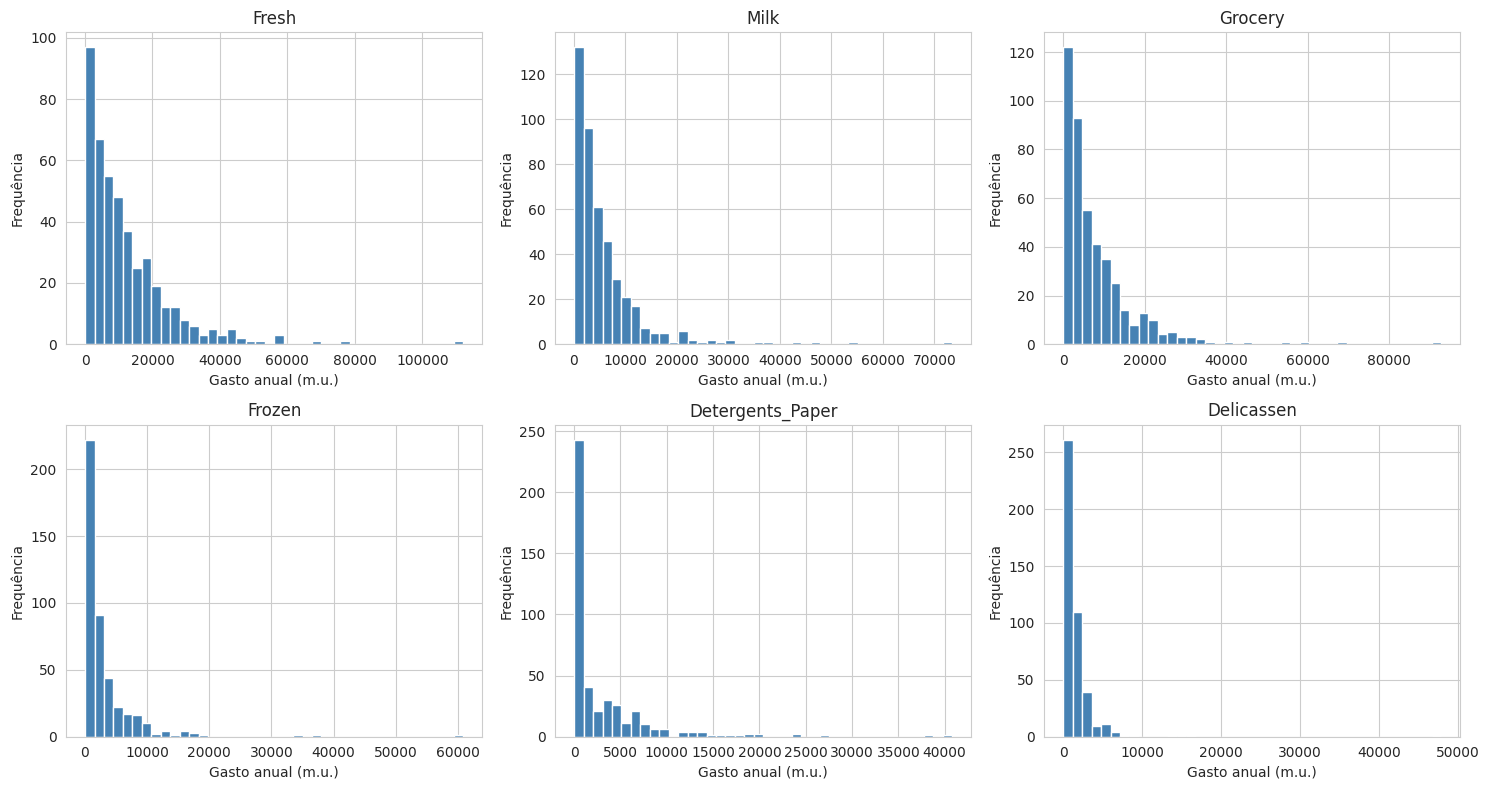

In [8]:
# Histogramas de cada variável de gasto para visualizar o formato das distribuições.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), spend_cols):
    ax.hist(df[col], bins=40, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel('Gasto anual (m.u.)')
    ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

**O que os histogramas mostram:**

Todas as seis categorias têm distribuições fortemente assimétricas à direita: a
maioria dos clientes se concentra em valores baixos de gasto, com uma cauda longa
de poucos clientes gastando muito. Esse formato confirma a leitura das estatísticas
descritivas e reforça a necessidade de uma transformação (como a logarítmica) para
tornar as distribuições mais simétricas antes da modelagem — algoritmos baseados em
distância, como o K-Means, tendem a ser prejudicados por caudas tão longas.

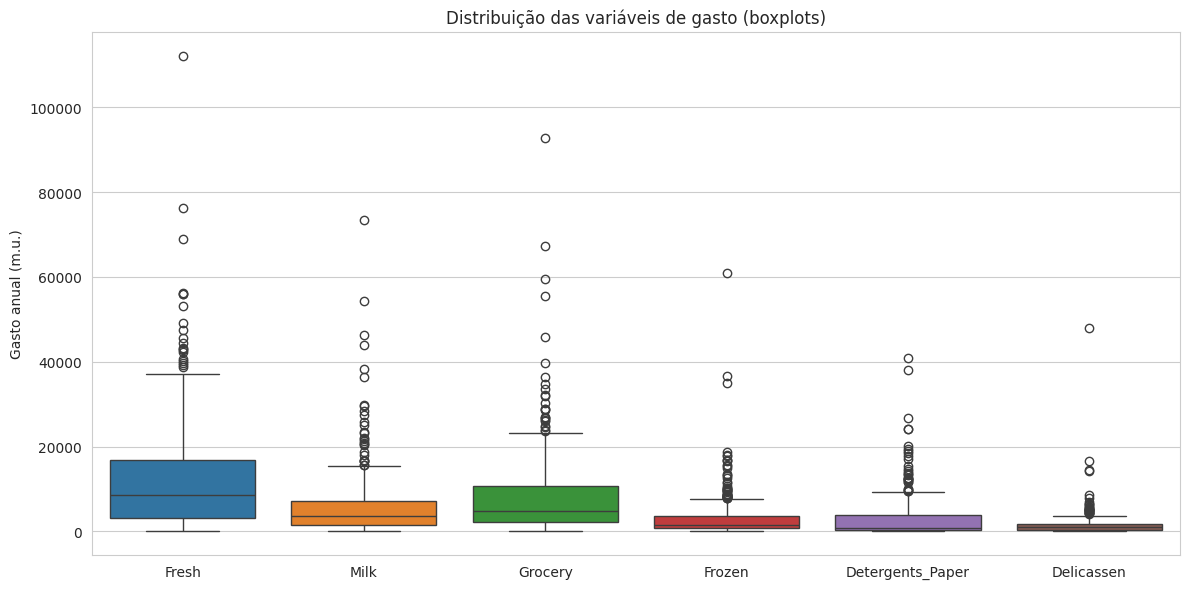

In [9]:
# Boxplots ajudam a enxergar a mediana, a dispersão e, principalmente, os outliers.
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df[spend_cols])
ax.set_title('Distribuição das variáveis de gasto (boxplots)')
ax.set_ylabel('Gasto anual (m.u.)')
plt.tight_layout()
plt.show()

**O que os boxplots mostram:**

Cada categoria apresenta um número considerável de pontos acima do limite superior
(outliers), especialmente Frozen, Detergents_Paper e Milk. Esses são clientes com
gastos muito acima do padrão em determinadas categorias. Como o volume de outliers é
grande e eles representam clientes reais (não erros de medição), não faz sentido
simplesmente removê-los — eles fazem parte do fenômeno. A transformação logarítmica
será uma forma de reduzir o peso desses valores extremos sem descartar informação.

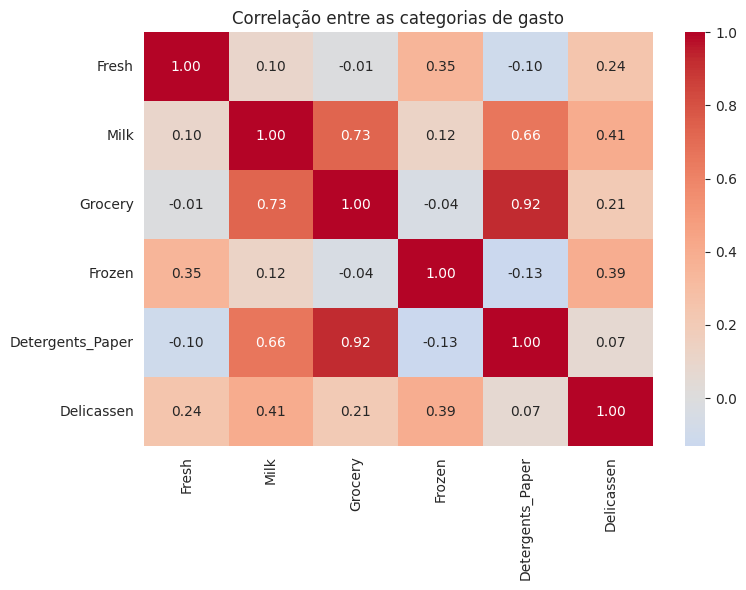

In [10]:
# Matriz de correlação entre as categorias de gasto.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[spend_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
ax.set_title('Correlação entre as categorias de gasto')
plt.tight_layout()
plt.show()

**O que o heatmap mostra:**

Há uma correlação muito forte entre **Grocery e Detergents_Paper (0,92)** e forte
entre **Grocery e Milk (0,73)**. Isso faz sentido no varejo: mercearia, laticínios
e produtos de limpeza/papel costumam ser comprados juntos por um mesmo perfil de
cliente. Já Fresh e Frozen têm correlações baixas com as demais, indicando um perfil
de consumo mais independente. Esses agrupamentos de variáveis são um bom indício de
que existem, de fato, perfis distintos de cliente — exatamente o que a clusterização
deve capturar.

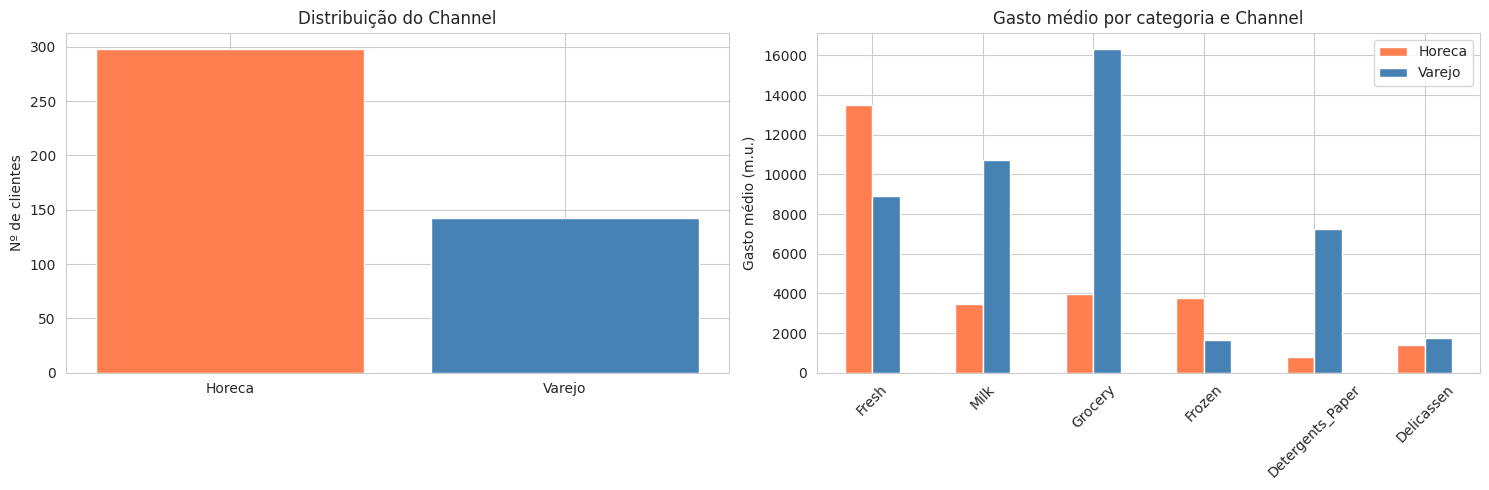

In [11]:
# Como não há target, usamos o Channel para explorar se os padrões de gasto se relacionam com um tipo de cliente já conhecido.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribuição do Channel
counts = df['Channel'].map({1: 'Horeca', 2: 'Varejo'}).value_counts()
axes[0].bar(counts.index, counts.values, color=['coral', 'steelblue'])
axes[0].set_title('Distribuição do Channel')
axes[0].set_ylabel('Nº de clientes')

# Gasto médio por categoria, separado por Channel
mean_by_ch = df.groupby('Channel')[spend_cols].mean()
mean_by_ch.index = ['Horeca', 'Varejo']
mean_by_ch.T.plot(kind='bar', ax=axes[1], color=['coral', 'steelblue'])
axes[1].set_title('Gasto médio por categoria e Channel')
axes[1].set_ylabel('Gasto médio (m.u.)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**O que a análise do Channel mostra:**

A base é desbalanceada: cerca de 298 clientes são do canal Horeca (hotéis,
restaurantes e cafés) e 142 do Varejo. Mais importante, os dois canais têm perfis
de gasto bem diferentes: clientes **Horeca** gastam mais com Fresh e Frozen, enquanto
clientes de **Varejo** gastam muito mais com Grocery, Milk e Detergents_Paper. Essa
separação clara é uma ótima notícia para o projeto: sugere que existe uma estrutura
real nos dados que a clusterização pode encontrar. Ao final, poderemos comparar os
grupos formados apenas a partir dos gastos com essa divisão Horeca/Varejo, para
avaliar se o modelo capturou esse padrão sem conhecê-lo de antemão.

### Hipóteses levantadas a partir da análise exploratória

1. As variáveis de gasto exigem **padronização**, pois estão em escalas diferentes,
   e uma **transformação logarítmica**, para reduzir a forte assimetria observada.
2. A alta correlação entre Grocery, Detergents_Paper e Milk sugere a existência de
   um perfil de cliente voltado a esses produtos (provavelmente o varejo).
3. A diferença de gasto entre Horeca e Varejo indica que há pelo menos dois perfis
   bem distintos, o que dá indícios de que a clusterização encontrará grupos coerentes.

## 4.1 Síntese da análise exploratória

A análise exploratória revelou um conjunto de dados limpo, porém com características
que exigem atenção na preparação. Não há valores ausentes nem duplicatas, o que
dispensa etapas de imputação ou limpeza de registros.

O ponto mais marcante são as **escalas muito diferentes** entre as variáveis de gasto
e a **forte assimetria à direita** presente em todas elas: a maioria dos clientes
gasta pouco, enquanto uma minoria gasta valores muito altos, gerando um grande número
de outliers em todas as categorias. Como esses outliers representam clientes reais, e
não erros, a estratégia não será removê-los, mas sim aplicar uma transformação
logarítmica para reduzir seu peso, seguida de padronização para colocar todas as
variáveis na mesma escala.

A análise de correlação mostrou grupos de variáveis que se movem juntas — em especial
Grocery, Detergents_Paper e Milk —, sugerindo a existência de perfis de compra
distintos. Isso é um bom indício de que a clusterização encontrará estrutura real nos
dados. Além disso, embora não haja um target no sentido tradicional, a variável Channel
mostrou-se desbalanceada (298 clientes Horeca contra 142 de Varejo) e associada a
padrões de gasto bem diferentes entre os dois canais, o que reforça a expectativa de
que existam ao menos dois perfis claros de cliente.

Esses achados orientam diretamente as próximas etapas: confirmam a necessidade de
transformação e padronização no pré-processamento, e sugerem que algoritmos baseados
em distância (como o K-Means) podem funcionar bem, desde que os dados sejam
adequadamente preparados.

> **Síntese:** os dados estão completos, mas apresentam escalas distintas e forte
> assimetria, exigindo transformação logarítmica e padronização antes da modelagem.
> As correlações e a diferença de perfil entre os canais indicam que há grupos reais
> a serem descobertos, favorecendo o uso de algoritmos de clusterização baseados em
> distância.


# 5. Preparação dos dados e divisão treino/teste

Nesta seção preparamos as variáveis para a modelagem: selecionamos os atributos que
serão usados, aplicamos a transformação logarítmica para reduzir a assimetria e
padronizamos os dados para que fiquem na mesma escala.

In [12]:
# Selecionamos apenas as seis variáveis de gasto para a modelagem. As colunas Channel e Region ficam de fora, conforme decidido no dicionário de dados.
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
X = df[spend_cols].copy()

# A coluna Channel é guardada separadamente. Ela não entra na modelagem, mas será usada mais adiante como referência externa para validar os grupos encontrados.
channel_true = df['Channel'].values

print(f"Variáveis usadas na modelagem: {X.shape[1]} colunas, {X.shape[0]} clientes.")

Variáveis usadas na modelagem: 6 colunas, 440 clientes.


In [13]:
# As variáveis de gasto têm forte assimetria à direita (visto na EDA). Aplicamos a transformação log1p, que calcula log(1 + x). Ela reduz o peso dos valores extremos
# e aproxima as distribuições de um formato mais simétrico. Usamos log1p em vez de log puro por segurança: caso algum valor fosse zero, log(1+0) = 0 não geraria erro.
X_log = np.log1p(X)

# Comparamos a assimetria antes e depois para confirmar o efeito da transformação.
skew_comparison = pd.DataFrame({
    'Antes (original)': X.skew(),
    'Depois (log1p)': X_log.skew()
}).round(2)
skew_comparison

,Antes (original),Depois (log1p)
Fresh,2.56,-1.58
Milk,4.05,-0.22
Grocery,3.59,-0.67
Frozen,5.91,-0.35
Detergents_Paper,3.63,-0.24
Delicassen,11.15,-1.09


In [14]:
# Depois de transformar, padronizamos com StandardScaler para que todas as variáveis fiquem na mesma escala (média 0 e desvio 1). Isso é essencial em clusterização
# baseada em distância: sem padronizar, variáveis com valores maiores dominariam o cálculo de distância só por causa da escala, e não por serem mais relevantes.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Voltamos para um DataFrame apenas para manter os nomes das colunas e facilitar a inspeção. Os algoritmos poderiam trabalhar direto com o array numérico.
X_scaled = pd.DataFrame(X_scaled, columns=spend_cols)

print("Dados padronizados (média ~0 e desvio ~1 em cada coluna):")
X_scaled.describe().round(2)

Dados padronizados (média ~0 e desvio ~1 em cada coluna):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.00,440.00,440.00,440.00,440.00,440.00
mean,0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-5.00,-3.79,-6.36,-3.16,-3.17,-4.09
25%,-0.47,-0.73,-0.69,-0.54,-0.73,-0.51
50%,0.21,0.07,0.02,0.02,-0.05,0.16
75%,0.68,0.70,0.75,0.68,0.87,0.65
max,1.97,2.86,2.70,2.90,2.24,3.18


## 5.1 Justificativa da divisão

Em problemas supervisionados, a divisão treino/teste serve para medir se o modelo
generaliza suas previsões para dados não vistos. Na clusterização, essa lógica não
se aplica da mesma forma: não há uma variável-alvo a ser prevista, e o objetivo é
descrever a estrutura de agrupamento dos clientes disponíveis, e não prever rótulos
para novos registros. Por isso, não foi utilizada uma divisão tradicional entre
treino e teste, nem validação cruzada nos moldes supervisionados.

Consequentemente, questões como proporção treino/teste e estratificação de classes
não se aplicam a este problema, já que não existe uma classe-alvo a ser preservada
entre as partições. A modelagem utiliza os 440 clientes disponíveis, buscando os
padrões de agrupamento presentes no conjunto como um todo.

A avaliação será conduzida por métricas internas de qualidade dos agrupamentos — o
silhouette score e o índice Davies-Bouldin —, que medem coesão e separação dos grupos
sem depender de rótulos. Como validação adicional, os grupos formados serão comparados
à variável Channel (reservada e não usada na modelagem) por meio do adjusted rand
score, para verificar se a estrutura encontrada tem relação com uma divisão real já
conhecida.

Sobre o **vazamento de dados**: embora não haja divisão treino/teste, o cuidado com
vazamento ainda é relevante na etapa de preparação. As transformações de log e
padronização foram ajustadas sobre o próprio conjunto que será agrupado, o que é
coerente com um cenário não-supervisionado em que todos os dados participam da
descoberta dos grupos. A variável Channel, que serve de referência externa, foi
mantida completamente separada do processo de modelagem, garantindo que a validação
final não seja contaminada pela informação que se deseja verificar.

> **Resposta:** por se tratar de clusterização, não há divisão treino/teste tradicional
> nem estratificação, pois não existe variável-alvo a prever. A modelagem usa todos os
> clientes e a avaliação se dá por métricas internas (silhouette e Davies-Bouldin),
> complementada pela comparação dos grupos com a variável Channel via adjusted rand score.

# 6. Pré-processamento e pipeline

Na Seção 5, as transformações foram aplicadas passo a passo para que seu efeito
pudesse ser observado individualmente. Aqui, reunimos essas mesmas etapas em um
**Pipeline** do scikit-learn, criando uma sequência de pré-processamento única e
reprodutível, que será usada na modelagem.

Organizar o pré-processamento em um pipeline traz duas vantagens: garante que as
transformações sejam sempre aplicadas na mesma ordem, e evita erros de aplicação
manual repetida — o que também é uma proteção contra vazamento de dados.


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

# Montamos o pipeline de pré-processamento com as duas etapas definidas na Seção 5:
#   1. log_transform: aplica log1p para reduzir a assimetria das variáveis de gasto. Como o log não é um transformador nativo do scikit-learn, usamos o FunctionTransformer, que "embrulha" a função np.log1p em um passo de pipeline.
#   2. scaler: padroniza os dados (média 0, desvio 1) para o cálculo de distância.
preprocessor = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor

Pipeline(steps=[('log_transform', FunctionTransformer(func=<ufunc 'log1p'>)),
                ('scaler', StandardScaler())])

In [16]:
# Aplicamos o pipeline às variáveis de gasto. O fit_transform executa as duas etapas em sequência e devolve os dados já prontos para a modelagem.
X_prepared = preprocessor.fit_transform(X)

# Convertendo de volta para DataFrame apenas para facilitar a inspeção visual.
X_prepared = pd.DataFrame(X_prepared, columns=spend_cols)

print(f"Dados prontos para modelagem: {X_prepared.shape[0]} clientes, {X_prepared.shape[1]} variáveis.")
X_prepared.head()

Dados prontos para modelagem: 440 clientes, 6 variáveis.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


Os dados agora estão prontos para a modelagem: com a assimetria reduzida pela
transformação logarítmica e todas as variáveis na mesma escala. O objeto `X_prepared`
será a entrada dos algoritmos de clusterização nas próximas seções.

## 6.1 Decisões de pré-processamento

**Transformação logarítmica.** As seis variáveis de gasto apresentavam forte
assimetria à direita, com muitos outliers de clientes que gastam valores muito
acima da média. Em vez de remover esses clientes — que são reais e fazem parte do
fenômeno —, optou-se por aplicar a transformação log1p, que reduz o peso dos valores
extremos e aproxima as distribuições de um formato mais simétrico. Isso é importante
porque algoritmos baseados em distância são sensíveis a caudas longas: sem a
transformação, poucos clientes de gasto muito alto dominariam a formação dos grupos.

**Padronização (StandardScaler).** Após a transformação, os dados foram padronizados
para média 0 e desvio 1. A padronização é essencial em clusterização baseada em
distância porque as variáveis, mesmo após o log, ainda teriam faixas de valores
diferentes. Sem padronizar, uma variável com valores maiores contribuiria mais para
o cálculo de distância apenas por causa de sua escala, e não por ser mais relevante.
Com a padronização, todas as variáveis passam a ter o mesmo peso inicial.

> **Resposta:** aplicou-se transformação logarítmica para reduzir a assimetria e a
> influência dos outliers, seguida de padronização para equalizar a escala das
> variáveis — ambas necessárias por se tratar de clusterização baseada em distância.
> As variáveis Channel e Region foram removidas da modelagem por razões distintas
> (validação externa e irrelevância geográfica), e não houve criação de novos atributos,
> priorizando a simplicidade e a interpretabilidade dos grupos.

# 7. Baseline e modelos candidatos

Nesta seção construímos os modelos de clusterização. A estratégia é começar por um
baseline simples e conhecido — o **K-Means** — e depois compará-lo com dois modelos
candidatos que funcionam por princípios diferentes: **DBSCAN** (baseado em densidade)
e **clusterização hierárquica** (aglomerativa).

O K-Means exige que se defina previamente o número de grupos (k). Por isso, antes de
treiná-lo, usamos duas ferramentas para escolher esse valor: o método do elbow e o
silhouette score.


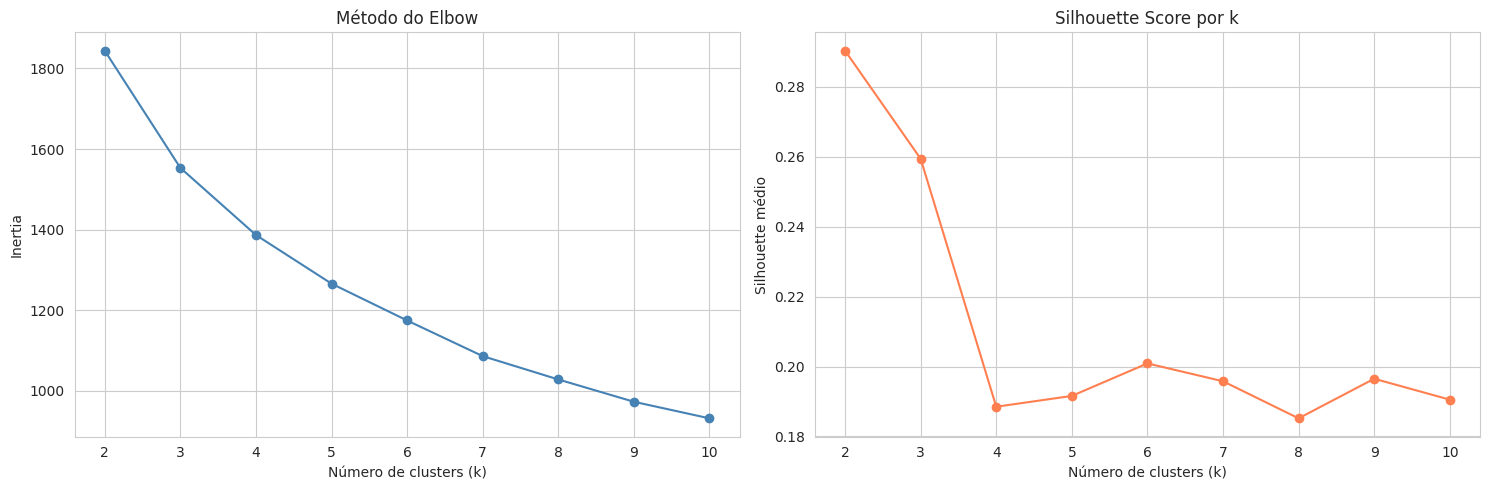

In [17]:
# O K-Means precisa que informemos o número de clusters (k). Para escolher um bom valor, testamos k de 2 a 10 e avaliamos dois critérios:
#   - Inertia (método do elbow): mede o quão compactos são os grupos. Sempre diminui ao aumentar k, então procuramos o ponto onde a queda desacelera.
#   - Silhouette: mede coesão e separação dos grupos. Quanto maior, melhor.
k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_prepared)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

# Visualizamos os dois critérios lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Método do Elbow')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(list(k_range), silhouettes, marker='o', color='coral')
axes[1].set_title('Silhouette Score por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette médio')

plt.tight_layout()
plt.show()

**O que os gráficos indicam:**

No método do elbow, a inertia cai de forma acentuada até k=2 e k=3, e a partir daí
passa a diminuir mais lentamente, formando o ponto de inflexão da curva. No silhouette,
o maior valor ocorre em **k=2** (cerca de 0,29), decaindo para valores de k maiores.
Os dois critérios apontam para uma solução com poucos grupos, e o silhouette favorece
claramente **dois grupos**.

Esse resultado é coerente com a análise exploratória: vimos que a variável Channel
divide os clientes em dois perfis de gasto bem distintos (Horeca e Varejo). Por isso,
adotamos **k=2** no K-Means baseline.

> **Decisão:** o K-Means será treinado com k=2, valor indicado pelo silhouette e
> coerente com a estrutura observada na EDA.

In [18]:
# Treinamos o K-Means com k=2, o valor escolhido na etapa anterior.
# n_init=10 faz o algoritmo rodar 10 vezes com inicializações diferentes e manter o melhor resultado, reduzindo a chance de cair em um agrupamento ruim por azar na inicialização aleatória dos centroides.
kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_prepared)

# Avaliamos com as três métricas definidas no projeto:
#   - silhouette e davies-bouldin: qualidade interna dos grupos
#   - adjusted rand: concordância com o Channel (validação externa)
print("K-Means (k=2)")
print(f"  Silhouette score : {silhouette_score(X_prepared, kmeans_labels):.4f}")
print(f"  Davies-Bouldin   : {davies_bouldin_score(X_prepared, kmeans_labels):.4f}")
print(f"  Adjusted Rand    : {adjusted_rand_score(channel_true, kmeans_labels):.4f}")
print(f"  Tamanho dos grupos: {np.bincount(kmeans_labels)}")

K-Means (k=2)
  Silhouette score : 0.2903
  Davies-Bouldin   : 1.3515
  Adjusted Rand    : 0.5135
  Tamanho dos grupos: [252 188]


**Resultado do K-Means:**

O K-Means dividiu os clientes em dois grupos de tamanhos equilibrados (252 e 188). O
silhouette de 0,29 indica uma separação moderada, e o adjusted rand de **0,51** em
relação ao Channel é o resultado mais relevante: os grupos formados apenas a partir
dos gastos têm concordância razoável com a divisão real entre Horeca e Varejo — ou
seja, o modelo recuperou parte de uma estrutura verdadeira sem conhecer o Channel.

> **Conclusão:** o baseline K-Means produz grupos coerentes e alinhados a um padrão
> real dos dados, servindo como uma boa referência para comparar os demais modelos.

In [19]:
# O DBSCAN agrupa por densidade: forma grupos onde há muitos pontos próximos e trata pontos isolados como outliers (rótulo -1).
# Ele não recebe o número de clusters quem determina isso são os parâmetros eps (raio de vizinhança) e min_samples.
# Testamos alguns valores de eps para entender o comportamento do algoritmo aqui.
print("DBSCAN — comportamento para diferentes valores de eps:")
for eps in [0.8, 1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=5)
    db_labels = db.fit_predict(X_prepared)
    n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    n_noise = (db_labels == -1).sum()
    print(f"  eps={eps}: {n_clusters} grupo(s), {n_noise} outliers")

DBSCAN — comportamento para diferentes valores de eps:
  eps=0.8: 3 grupo(s), 230 outliers
  eps=1.0: 1 grupo(s), 124 outliers
  eps=1.5: 1 grupo(s), 41 outliers
  eps=2.0: 1 grupo(s), 12 outliers


**Resultado do DBSCAN:**

O DBSCAN não se mostrou adequado a este conjunto de dados. Com raio de vizinhança
pequeno (eps baixo), ele classifica a maioria dos clientes como outliers; com raio
maior, junta praticamente todos em um único grupo. Em nenhuma configuração ele
encontra dois ou mais grupos densos e equilibrados.

A razão é conceitual: o DBSCAN funciona bem quando existem regiões de alta densidade
separadas por áreas claramente vazias. Após a transformação e a padronização, os
gastos dos clientes formam uma nuvem relativamente contínua, sem "vales" de densidade
que separem os grupos. Sem essas fronteiras naturais, o algoritmo não consegue
delimitar clusters — ele foi projetado justamente para dados com essa estrutura de
densidade, que não é o caso aqui.

> **Conclusão:** o DBSCAN não é apropriado para este dataset. Esse resultado é útil
> por si só: mostra que a escolha do algoritmo depende do formato dos dados, e não há
> um método de clusterização universalmente melhor.

In [20]:
# A clusterização hierárquica aglomerativa começa com cada cliente em seu próprio grupo e vai unindo os mais próximos, passo a passo, até restar o número de grupos
# desejado. Diferente do K-Means, não depende de inicialização aleatória. Usamos n_clusters=2 para comparar diretamente com o baseline.
agglomerative = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglomerative.fit_predict(X_prepared)

print("Agglomerative (n_clusters=2)")
print(f"  Silhouette score : {silhouette_score(X_prepared, agglo_labels):.4f}")
print(f"  Davies-Bouldin   : {davies_bouldin_score(X_prepared, agglo_labels):.4f}")
print(f"  Adjusted Rand    : {adjusted_rand_score(channel_true, agglo_labels):.4f}")
print(f"  Tamanho dos grupos: {np.bincount(agglo_labels)}")

Agglomerative (n_clusters=2)
  Silhouette score : 0.2585
  Davies-Bouldin   : 1.6004
  Adjusted Rand    : 0.5392
  Tamanho dos grupos: [178 262]


**Resultado da clusterização hierárquica:**

O modelo hierárquico produziu resultados muito semelhantes ao K-Means: dois grupos
de tamanhos próximos (178 e 262), silhouette de 0,26 e adjusted rand de **0,54** em
relação ao Channel — inclusive um pouco superior ao baseline nessa validação externa.

O fato de dois algoritmos diferentes (K-Means e hierárquico) chegarem a agrupamentos
parecidos é um bom sinal: reforça que a estrutura de dois perfis de cliente é real e
estável, e não um artefato de um método específico.

> **Conclusão:** o modelo hierárquico confirma a divisão em dois grupos encontrada
> pelo baseline, com desempenho equivalente e boa concordância com o Channel.

## 7.1 Justificativa dos modelos

**O baseline (K-Means) é coerente?** Sim. O K-Means é o algoritmo de clusterização
mais simples e difundido, o que o torna uma referência natural. Ele parte de uma ideia
direta — agrupar os clientes em torno de centros — e serve para estabelecer um patamar
contra o qual avaliar se os demais modelos trazem ganho. Além disso, seu resultado se
mostrou coerente com a estrutura real dos dados (a divisão Horeca/Varejo).

**Os candidatos são adequados ao tipo e tamanho dos dados?** Os dois candidatos foram
escolhidos por representarem princípios de agrupamento diferentes do baseline, o que
enriquece a comparação. O DBSCAN agrupa por densidade e tem a vantagem de detectar
outliers e descobrir o número de grupos sozinho. A clusterização hierárquica agrupa de
forma aglomerativa e não depende de inicialização aleatória. Para um dataset pequeno
como este (440 registros), todos os três são computacionalmente viáveis e rodam de
forma praticamente instantânea.

**Algum modelo exige tratamento específico?** Sim, e isso foi feito no pré-processamento.
Os três algoritmos são baseados em distância, o que torna a padronização essencial —
sem ela, variáveis de maior escala dominariam o agrupamento. O DBSCAN é particularmente
sensível à escala dos dados por causa do parâmetro de raio (eps), o que reforça a
importância da preparação feita na Seção 6.

**Restrições de interpretabilidade, tempo ou custo?** O foco do projeto é a
interpretabilidade dos grupos, e não a maximização de uma métrica. Por isso, modelos
que produzem grupos claros e descritíveis (como o K-Means e o hierárquico com k=2) são
preferíveis a soluções mais complexas e difíceis de explicar. O custo computacional não
é uma restrição, dado o tamanho reduzido da base.

> **Resposta:** o K-Means foi adotado como baseline por sua simplicidade e ampla
> utilização. DBSCAN e clusterização hierárquica foram escolhidos como candidatos por
> seguirem princípios distintos (densidade e aglomeração), permitindo uma comparação
> rica. Todos exigem padronização por serem baseados em distância, o que foi tratado no
> pré-processamento. Como o dataset é pequeno, não há restrições de custo, e a prioridade
> é a interpretabilidade dos grupos.


# 8. Treinamento e avaliação inicial

Os três modelos definidos na seção anterior — K-Means (baseline), DBSCAN e
clusterização hierárquica — foram treinados sobre os dados preparados. Nesta seção,
apresentamos e interpretamos os resultados iniciais de cada um.

In [21]:
# Reunimos aqui os resultados dos três modelos já treinados, para interpretá-los. Cada modelo gera um conjunto de rótulos (a que grupo cada cliente foi atribuído).

# K-Means (baseline)
kmeans_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_prepared)

# DBSCAN
dbscan_labels = DBSCAN(eps=0.8, min_samples=5).fit_predict(X_prepared)

# Clusterização hierárquica
agglo_labels = AgglomerativeClustering(n_clusters=2).fit_predict(X_prepared)

# Exibimos as métricas de cada modelo individualmente para leitura
print("K-Means (k=2)")
print(f"  Silhouette: {silhouette_score(X_prepared, kmeans_labels):.4f} | "
      f"Davies-Bouldin: {davies_bouldin_score(X_prepared, kmeans_labels):.4f} | "
      f"Adjusted Rand: {adjusted_rand_score(channel_true, kmeans_labels):.4f}")

print("\nAgglomerative (n=2)")
print(f"  Silhouette: {silhouette_score(X_prepared, agglo_labels):.4f} | "
      f"Davies-Bouldin: {davies_bouldin_score(X_prepared, agglo_labels):.4f} | "
      f"Adjusted Rand: {adjusted_rand_score(channel_true, agglo_labels):.4f}")

# Para o DBSCAN, precisamos considerar os outliers (rótulo -1)
n_noise = (dbscan_labels == -1).sum()
n_grupos_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
print(f"\nDBSCAN (eps=0.8)")
print(f"  Grupos formados: {n_grupos_db} | Outliers: {n_noise} de {len(dbscan_labels)} clientes | "
      f"Adjusted Rand: {adjusted_rand_score(channel_true, dbscan_labels):.4f}")

K-Means (k=2)
  Silhouette: 0.2903 | Davies-Bouldin: 1.3515 | Adjusted Rand: 0.5135

Agglomerative (n=2)
  Silhouette: 0.2585 | Davies-Bouldin: 1.6004 | Adjusted Rand: 0.5392

DBSCAN (eps=0.8)
  Grupos formados: 3 | Outliers: 230 de 440 clientes | Adjusted Rand: 0.0283


## 8.1 Análise dos resultados iniciais

**O modelo superou o baseline?** Em clusterização, a comparação não é de "vencedor
único", mas de adequação. O K-Means (baseline) e o modelo hierárquico apresentaram
desempenho muito parecido, com silhouette em torno de 0,26–0,29 e adjusted rand de
0,51 e 0,54 em relação ao Channel. O hierárquico ficou ligeiramente à frente na
validação externa, mas sem diferença expressiva. Os candidatos não superaram
claramente o baseline — eles o **confirmaram**, o que reforça a confiabilidade da
solução de dois grupos.

**A métrica escolhida é suficiente?** Este é o ponto mais importante da análise. O
DBSCAN aparenta bom desempenho nas métricas internas, mas isso é enganoso: ele obtém
esses números porque descarta cerca de metade dos clientes como outliers, avaliando
apenas os pontos mais fáceis. Seu adjusted rand próximo de zero revela que, na prática,
ele não capturou a estrutura real dos dados. Isso mostra que **nenhuma métrica isolada
é suficiente**: foi a combinação de métricas internas com a validação externa que
permitiu uma avaliação honesta.

**Algum modelo sofre de underfitting?** O conceito é típico de modelos supervisionados,
mas há um paralelo: o DBSCAN, ao não formar grupos coerentes e tratar tantos pontos
como ruído, essencialmente falha em capturar a estrutura dos dados — comportamento
análogo a um modelo que não aprende o padrão.

**O tempo de treinamento é aceitável?** Sim. Todos os modelos treinam em frações de
segundo, graças ao tamanho reduzido da base (440 clientes). Não há restrição de custo
computacional neste projeto.

**O resultado faz sentido considerando a EDA?** Sim, e de forma consistente. A EDA já
apontava para dois perfis distintos de cliente. O fato de dois algoritmos independentes
convergirem para dois grupos alinhados ao Channel confirma essa leitura inicial.

> **Resposta:** os modelos baseados em distância (K-Means e hierárquico) produziram
> resultados coerentes e equivalentes, confirmando a estrutura de dois grupos sugerida
> pela EDA e validada pelo Channel. O DBSCAN evidenciou a importância de não confiar em
> uma única métrica: suas métricas internas pareciam boas, mas a validação externa
> revelou que ele não capturou os grupos reais. O tempo de treino foi desprezível.

# 9. Validação e otimização de hiperparâmetros

Nesta seção, realizamos a otimização de hiperparâmetros em dois modelos, cobrindo os
dois cenários possíveis: um modelo que já apresentou bom desempenho (a clusterização
hierárquica) e um modelo que não formou grupos coerentes na avaliação inicial (o DBSCAN).

Como se trata de clusterização, a busca é feita de forma manual em grade, avaliando cada
configuração pelas métricas de agrupamento — e não com GridSearchCV, que é voltado a
problemas supervisionados com validação cruzada baseada em rótulos.

In [22]:
# Otimização 1: clusterização hierárquica.
# O principal hiperparâmetro do modelo aglomerativo é o linkage, que define o critério para unir os grupos a cada passo. Testamos as quatro opções disponíveis para verificar
# qual produz os melhores agrupamentos. Além das métricas, registramos o tamanho do menor grupo, que ajuda a identificar soluções degeneradas (um grupo quase vazio).
linkage_results = []
for link in ['ward', 'complete', 'average', 'single']:
    labels = AgglomerativeClustering(n_clusters=2, linkage=link).fit_predict(X_prepared)
    linkage_results.append({
        'linkage': link,
        'silhouette': silhouette_score(X_prepared, labels),
        'davies_bouldin': davies_bouldin_score(X_prepared, labels),
        'adj_rand': adjusted_rand_score(channel_true, labels),
        'menor_grupo': int(np.bincount(labels).min())
    })

linkage_df = pd.DataFrame(linkage_results).round(4)
linkage_df

,linkage,silhouette,davies_bouldin,adj_rand,menor_grupo
0,ward,0.2585,1.6004,0.5392,178
1,complete,0.3220,1.5543,-0.0550,38
2,average,0.5691,0.8826,-0.0047,2
3,single,0.5700,0.3067,-0.0024,1


**O que a busca por linkage revelou:**

À primeira vista, os linkages `average` e `single` parecem os melhores, com silhouette
acima de 0,56. No entanto, a coluna do menor grupo desmascara esse resultado: esses
linkages formam um grupo com quase todos os clientes e outro com apenas 1 ou 2 — uma
solução degenerada, sem utilidade prática. O adjusted rand próximo de zero confirma que
esses agrupamentos não têm relação com a estrutura real dos dados.

O linkage **ward**, apesar de ter o menor silhouette entre as opções, é o único que
forma dois grupos equilibrados (178 e 262 clientes) e com forte concordância com o
Channel (adjusted rand de 0,54). Ele é, portanto, a melhor configuração — e coincide
com o padrão que já vínhamos utilizando.

> **Melhor configuração:** linkage = ward, que produz grupos equilibrados e coerentes
> com a estrutura real, ao contrário das demais opções, que geram soluções degeneradas.

In [23]:
# Otimização 2: DBSCAN.
# Na avaliação inicial, o DBSCAN foi o único modelo que não formou grupos coerentes. Antes de descartá-lo, fazemos uma busca sistemática em seus dois hiperparâmetros
# principais (eps e min_samples) para verificar se alguma configuração o torna competitivo.
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5]
min_samples_values = [3, 5, 10, 15]

search_results = []
for eps in eps_values:
    for ms in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_prepared)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_prepared[mask], labels[mask])
        else:
            sil = np.nan
        ari = adjusted_rand_score(channel_true, labels)
        search_results.append({
            'eps': eps, 'min_samples': ms, 'grupos': n_clusters,
            'outliers': n_noise, 'silhouette': sil, 'adj_rand': ari
        })

search_df = pd.DataFrame(search_results)
search_df[search_df['grupos'] >= 2].round(4)

,eps,min_samples,grupos,outliers,silhouette,adj_rand
0,0.5,3,8,396,0.4175,0.0674
4,0.8,3,8,176,-0.1802,0.0198
5,0.8,5,3,230,0.2885,0.0283
6,0.8,10,2,334,0.5372,0.0454
7,0.8,15,2,392,0.5924,0.0741
8,1.0,3,6,91,-0.1016,-0.0242
12,1.2,3,4,61,-0.0140,-0.0227
16,1.5,3,2,35,0.3973,-0.0231


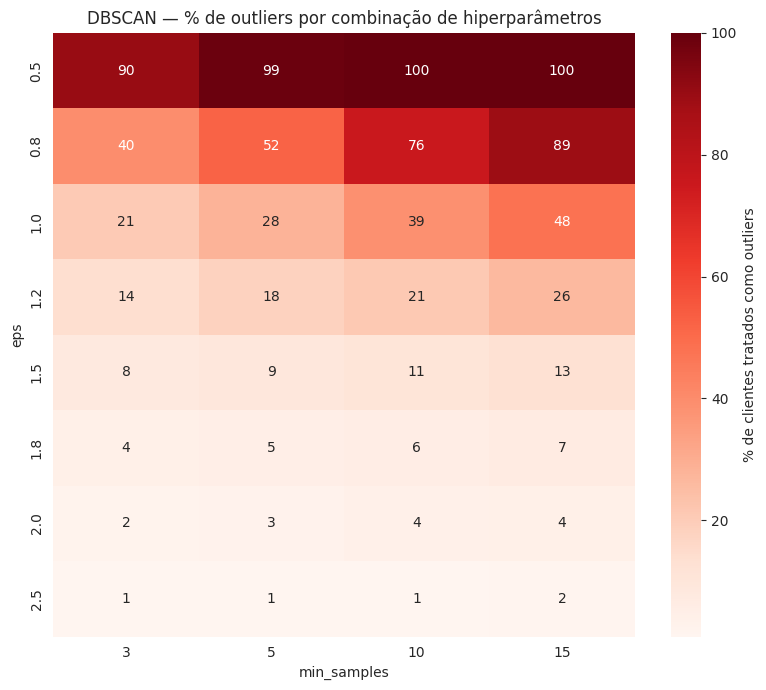

In [24]:
# Visualizamos a proporção de outliers gerada por cada combinação. Isso deixa claro o principal problema do DBSCAN neste dataset: para formar grupos, ele precisa descartar uma grande parte dos clientes.
noise_matrix = search_df.pivot(index='eps', columns='min_samples', values='outliers')
noise_matrix = (noise_matrix / len(X_prepared) * 100)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(noise_matrix, annot=True, fmt='.0f', cmap='Reds',
            cbar_kws={'label': '% de clientes tratados como outliers'})
ax.set_title('DBSCAN — % de outliers por combinação de hiperparâmetros')
ax.set_xlabel('min_samples')
ax.set_ylabel('eps')
plt.tight_layout()
plt.show()

**O que a busca do DBSCAN revelou:**

Nenhuma combinação de hiperparâmetros tornou o DBSCAN adequado. As configurações que
alcançam silhouette alto só conseguem esse número porque descartam a grande maioria dos
clientes como outliers — em alguns casos, quase 90% deles. Ou seja, o bom silhouette é
obtido avaliando apenas um punhado de pontos fáceis, o que não representa uma solução útil.

Quando limitamos a busca a configurações com uma proporção razoável de outliers, o melhor
resultado alcança adjusted rand próximo de zero (ou até negativo) em relação ao Channel —
confirmando que os grupos formados não têm relação com a estrutura real dos dados.

> **Melhor configuração:** não há uma configuração satisfatória. A busca sistemática
> confirmou que o DBSCAN é inadequado para este conjunto de dados, independentemente do
> ajuste de hiperparâmetros.

## 9.1 Discussão da otimização

**A otimização melhorou o resultado?** Os dois casos trouxeram aprendizados diferentes.
Na clusterização hierárquica, a busca confirmou que o linkage `ward` — já utilizado — é
de fato a melhor opção, evitando as soluções degeneradas produzidas pelos outros linkages.
No DBSCAN, a busca não encontrou nenhuma configuração competitiva; seu resultado não foi
um modelo melhor, mas uma conclusão bem fundamentada sobre sua inadequação a estes dados.

**A busca foi limitada por tempo, custo ou tamanho da base?** Não. Como a base é pequena,
foi possível testar todas as configurações (as quatro opções de linkage e as 32
combinações do DBSCAN) em poucos segundos, sem qualquer restrição de custo computacional.

**Os hiperparâmetros escolhidos fazem sentido?** Sim. No caso hierárquico, o linkage é o
hiperparâmetro que mais afeta o formato dos grupos, então testá-lo é a escolha natural. No
DBSCAN, eps e min_samples são justamente os parâmetros que controlam a densidade exigida
para formar grupos, e a grade cobriu uma faixa ampla, do muito restritivo ao muito permissivo.

**Testaria outras combinações com mais tempo?** Para a clusterização hierárquica, as
opções de linkage já foram esgotadas. Para o DBSCAN, combinações adicionais dentro da mesma
grade dificilmente mudariam a conclusão, já que o comportamento do algoritmo se mostrou
consistente em toda a faixa testada. Uma investigação futura interessante seria explorar
transformações no espaço de atributos antes de aplicar o DBSCAN, para verificar se isso o
tornaria mais adequado a estes dados.

> **Resposta:** a otimização confirmou o linkage `ward` como a melhor configuração da
> clusterização hierárquica e demonstrou, de forma metódica, que o DBSCAN permanece
> inadequado a estes dados independentemente do ajuste. Em ambos os casos, a busca reforçou
> a importância de avaliar os grupos por múltiplas métricas, e não apenas pelo silhouette —
> que, isolado, favoreceria soluções degeneradas.

# 10. Análise do modelo escolhido

Como este é um problema de clusterização, não há um conjunto de teste separado para uma
avaliação final nos moldes supervisionados — a justificativa está na Seção 5.1. Em vez
disso, esta seção aprofunda a análise do **modelo escolhido**, interpretando o que os
grupos encontrados representam na prática.

O modelo selecionado foi o **K-Means (k=2)**. Entre ele e a clusterização hierárquica,
cujos desempenhos foram praticamente equivalentes, optou-se pelo K-Means por ser o modelo
mais simples e interpretável: seus grupos são organizados em torno de centros bem
definidos, o que facilita a descrição de cada perfil. Quando dois modelos têm desempenho
semelhante, a escolha do mais simples é preferível.


In [25]:
# Treinamos o modelo escolhido e analisamos o perfil de cada grupo.
# Importante: para interpretar os grupos, usamos os valores de gasto ORIGINAIS (não transformados), pois eles estão na escala real (unidades monetárias) e são muito mais fáceis de interpretar do que os valores padronizados.
kmeans_final = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_prepared)

# Juntamos os rótulos aos gastos reais para calcular o perfil médio de cada cluster
df_profile = df[spend_cols].copy()
df_profile['cluster'] = kmeans_labels

profile = df_profile.groupby('cluster')[spend_cols].mean().round(0)
print("Gasto médio anual (em unidades monetárias) por cluster:")
profile

Gasto médio anual (em unidades monetárias) por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,13973.0,2402.0,2919.0,3706.0,492.0,1038.0
1,9356.0,10346.0,14697.0,2222.0,6085.0,2177.0


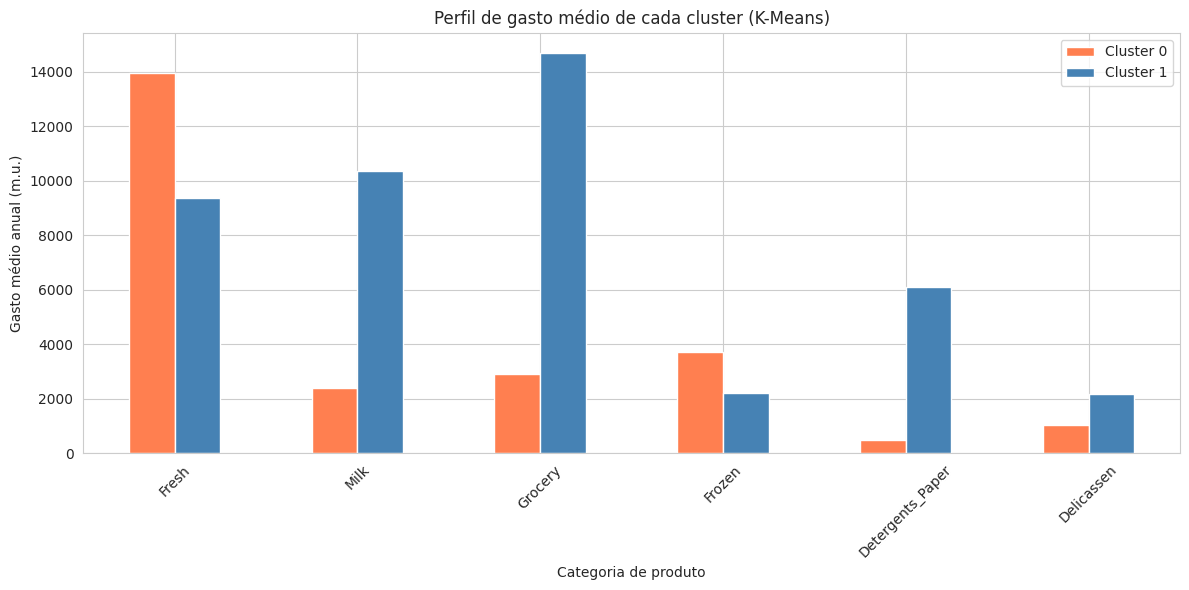

In [26]:
# Gráfico de barras comparando o perfil de gasto dos dois grupos.
fig, ax = plt.subplots(figsize=(12, 6))
profile.T.plot(kind='bar', ax=ax, color=['coral', 'steelblue'])
ax.set_title('Perfil de gasto médio de cada cluster (K-Means)')
ax.set_ylabel('Gasto médio anual (m.u.)')
ax.set_xlabel('Categoria de produto')
ax.legend(['Cluster 0', 'Cluster 1'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Interpretação dos grupos:**

Os dois clusters têm perfis de consumo bem distintos:

- **Cluster 0 (252 clientes)** — concentra os maiores gastos em **Fresh** e **Frozen**,
  com baixo consumo de mercearia e produtos de limpeza. É o perfil típico de
  estabelecimentos que trabalham com ingredientes frescos e congelados, como
  restaurantes, hotéis e cafés.

- **Cluster 1 (188 clientes)** — concentra os maiores gastos em **Grocery**, **Milk** e
  **Detergents_Paper**. É o perfil típico de comércios de revenda, como mercados e lojas
  de varejo, que compram mercearia, laticínios e itens de limpeza em volume.

> **Conclusão:** o modelo separou os clientes em dois perfis claros e interpretáveis —
> um voltado a alimentos frescos/congelados e outro a mercearia e revenda —, exatamente
> o tipo de segmentação útil para decisões de marketing e operação.

In [27]:
# Cruzamos os clusters encontrados com a variável Channel, que foi reservada e nunca usada na modelagem.
# Isso funciona como uma validação externa: verifica se os grupos formados apenas a partir dos gastos correspondem a uma divisão real já conhecida.
crosstab = pd.crosstab(kmeans_labels, df['Channel'],
                       rownames=['Cluster'], colnames=['Channel'])
crosstab.columns = ['Horeca', 'Varejo']
print("Distribuição dos clusters em relação ao Channel real:")
crosstab

Distribuição dos clusters em relação ao Channel real:


,Horeca,Varejo
Cluster,,
0,244,8
1,54,134


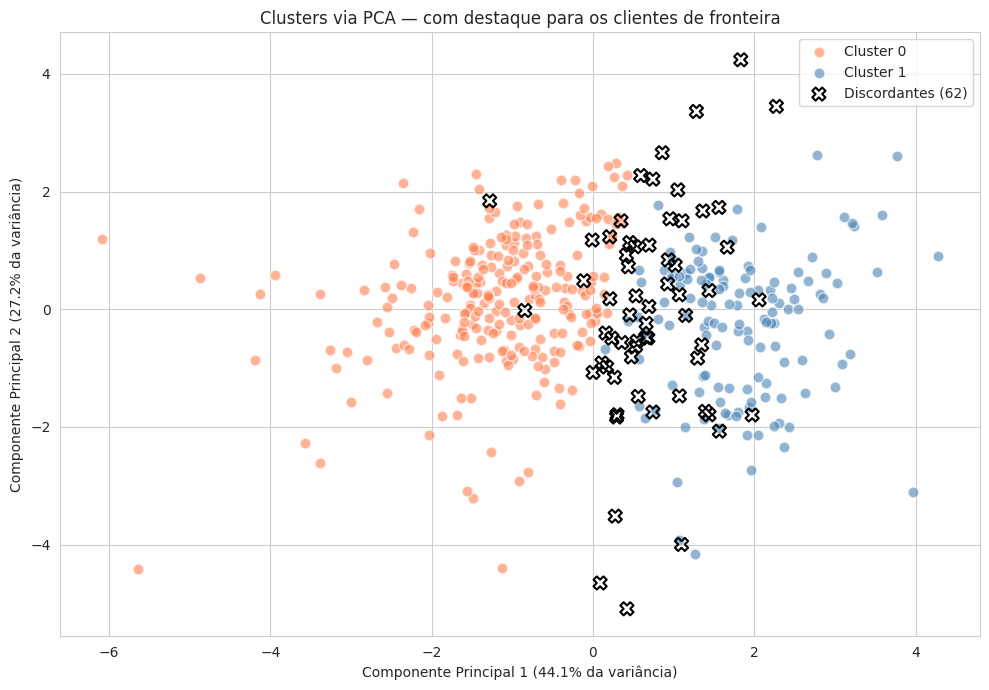

In [28]:
# Além da tabela, vale visualizar espacialmente como os grupos se separam e, sobretudo, ONDE estão os clientes de fronteira. Como temos seis variáveis de gasto, usamos o PCA
# para reduzir esse espaço a dois componentes e conseguir plotar em 2D. O PCA combina as variáveis originais em novos eixos que preservam o máximo possível da variação dos dados.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_prepared)
var_ratio = pca.explained_variance_ratio_

# Marcamos os clientes "discordantes": aqueles cujo cluster não corresponde ao Channel real. O Cluster 0 ficou associado a Horeca (canal 1) e o Cluster 1 a Varejo (canal 2).
channel_esperado = np.where(kmeans_labels == 0, 1, 2)
discordante = channel_esperado != channel_true

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['coral', 'steelblue']
for c in [0, 1]:
    mask = (kmeans_labels == c) & (~discordante)
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[c],
               label=f'Cluster {c}', alpha=0.6, edgecolors='white', s=60)
ax.scatter(X_pca[discordante, 0], X_pca[discordante, 1],
           c='none', edgecolors='black', marker='X', s=90, linewidths=1.5,
           label=f'Discordantes ({discordante.sum()})')
ax.set_title('Clusters via PCA — com destaque para os clientes de fronteira')
ax.set_xlabel(f'Componente Principal 1 ({var_ratio[0]:.1%} da variância)')
ax.set_ylabel(f'Componente Principal 2 ({var_ratio[1]:.1%} da variância)')
ax.legend()
plt.tight_layout()
plt.show()

**O que a validação mostra:**

O cruzamento confirma a interpretação: dos 252 clientes do Cluster 0, 244 são de fato
do canal Horeca; e o Cluster 1 concentra a maioria dos clientes de Varejo (134 de 188).
Ou seja, o modelo — que nunca teve acesso à variável Channel — reconstruiu quase
integralmente a divisão real entre os dois tipos de cliente, apenas a partir dos padrões
de gasto.

A visualização via PCA reforça essa leitura: os dois grupos aparecem como nuvens de
pontos bem definidas, e os 62 clientes discordantes concentram-se justamente na região
de fronteira entre eles. Isso mostra que as discordâncias não são erros aleatórios, mas
clientes de comportamento intermediário, cujo padrão de gasto fica no limite entre os
dois perfis — os casos naturalmente mais difíceis de classificar.

> **Validação:** com adjusted rand de 0,51, os grupos formados têm forte correspondência
> com a divisão Horeca/Varejo, confirmando a hipótese de que os perfis de gasto refletem
> uma estrutura real do negócio. Os poucos casos discordantes situam-se na fronteira entre
> os grupos, como esperado.

## 10.1 Análise de erros e limitações

**Que tipo de "erro" o modelo comete?** Como não há rótulos verdadeiros guiando a
clusterização, o "erro" aqui é entendido como a discordância em relação ao Channel. O
modelo classificou cerca de 62 clientes em um grupo cujo perfil de gasto não corresponde
ao seu canal real (por exemplo, clientes Horeca com padrão de consumo mais parecido com
o de varejo). Esses casos representam clientes de comportamento "híbrido", que compram de
forma diferente do típico de seu canal — não são exatamente erros, mas fronteiras naturais
entre os grupos.

**Há sinais de overfitting ou underfitting?** Esses conceitos não se aplicam diretamente à
clusterização, que não aprende a prever um alvo. Ainda assim, vale notar que o modelo não
"decorou" os dados: ele encontrou uma estrutura simples (dois grupos) que se mostrou
coerente tanto internamente (silhouette) quanto com uma referência externa (Channel).

**A métrica escolhida captura bem o objetivo?** Sim. O silhouette avaliou a qualidade
interna dos grupos, e o adjusted rand permitiu validar os grupos contra uma divisão real.
A combinação das duas foi essencial: como visto na modelagem, o silhouette isolado poderia
favorecer soluções enganosas.

**Há viés ou limitações nos dados?** Sim. O dataset representa clientes de uma região
específica de Portugal, então os perfis encontrados podem não se generalizar para outros
mercados. Além disso, os dados refletem apenas gastos anuais agregados em seis categorias,
sem informações como frequência de compra, sazonalidade ou porte do cliente, que poderiam
refinar a segmentação.

**Em quais cenários o modelo não deveria ser usado?** O modelo não deve ser usado para
decisões individuais de alto impacto sobre um cliente específico, já que descreve padrões
gerais de grupo e comete "erros" nas fronteiras. Ele também não deve ser aplicado a
clientes de perfil muito diferente dos presentes na base (por exemplo, de outros países
ou setores) sem uma nova validação.

> **Resposta:** o modelo separa bem os dois perfis principais de cliente, mas comete
> discordâncias nas fronteiras, onde há clientes de comportamento híbrido. Suas principais
> limitações são a abrangência geográfica restrita e o uso apenas de gastos agregados. É
> adequado para orientar estratégias gerais de segmentação, mas não para decisões
> individuais críticas.

## 10.2 Verificação das hipóteses

Retomando as três hipóteses levantadas na Seção 1.4, à luz dos resultados obtidos:

**Hipótese 1 — Existem perfis distintos de clientes na base.**
*Confirmada.* A modelagem identificou dois grupos bem definidos e interpretáveis: um
voltado a alimentos frescos e congelados (perfil Horeca) e outro a mercearia, laticínios
e produtos de limpeza (perfil Varejo). Os padrões de gasto não são homogêneos, e os
grupos têm características próprias e coerentes.

**Hipótese 2 — As variáveis de gasto exigem transformação e padronização.**
*Confirmada.* A análise exploratória revelou forte assimetria (com skewness chegando a
11 em algumas categorias) e escalas muito diferentes entre as variáveis. A transformação
logarítmica e a padronização foram, de fato, necessárias, e os modelos baseados em
distância só produziram grupos coerentes após esse tratamento.

**Hipótese 3 — Os grupos terão relação com o tipo de cliente (Channel).**
*Confirmada, com ressalvas.* A validação externa mostrou forte correspondência entre os
grupos e o Channel: 378 dos 440 clientes (86%) foram agrupados de forma coerente com seu
canal real, resultando em um adjusted rand de 0,51. Isso indica que os clusters capturam
uma estrutura real, e não ruído. A ressalva fica por conta dos 62 clientes discordantes,
situados na fronteira entre os grupos — clientes de comportamento intermediário, cujo
padrão de gasto não corresponde exatamente ao típico de seu canal.

> **Síntese:** as três hipóteses se confirmaram. A estrutura de dois perfis existe, a
> preparação dos dados foi necessária como previsto, e os grupos formados refletem uma
> divisão real do negócio — com a ressalva natural de que as fronteiras entre perfis
> comportam clientes de comportamento misto.

# 11. Comparação final dos modelos

Esta seção reúne os resultados de todos os modelos em uma única tabela comparativa,
consolidando as métricas obtidas ao longo do projeto e justificando a escolha do modelo
final. Para o DBSCAN e a clusterização hierárquica, são apresentadas suas melhores
configurações após a otimização.

In [29]:
import time

# Reunimos os três modelos em suas melhores configurações para a comparação final.
# A função calcula as mesmas métricas para todos, garantindo uma comparação justa.
def metrics_row(name, labels, tempo):
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    if n_clusters >= 2:
        sil = round(silhouette_score(X_prepared[mask], labels[mask]), 3)
        db = round(davies_bouldin_score(X_prepared[mask], labels[mask]), 3)
    else:
        sil, db = np.nan, np.nan
    ari = round(adjusted_rand_score(channel_true, labels), 3)
    return {'Modelo': name, 'Silhouette': sil, 'Davies-Bouldin': db,
            'Adjusted Rand': ari, 'Nº grupos': n_clusters, 'Tempo (s)': round(tempo, 4)}

rows = []

t0 = time.time()
labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_prepared)
rows.append(metrics_row('K-Means (k=2) — baseline', labels, time.time() - t0))

t0 = time.time()
labels = DBSCAN(eps=0.8, min_samples=5).fit_predict(X_prepared)
rows.append(metrics_row('DBSCAN (eps=0.8)', labels, time.time() - t0))

t0 = time.time()
labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X_prepared)
rows.append(metrics_row('Agglomerative (ward)', labels, time.time() - t0))

comparison_final = pd.DataFrame(rows).set_index('Modelo')
comparison_final

,Silhouette,Davies-Bouldin,Adjusted Rand,Nº grupos,Tempo (s)
Modelo,,,,,
K-Means (k=2) — baseline,0.290,1.352,0.514,2,0.0481
DBSCAN (eps=0.8),0.288,0.712,0.028,3,0.0080
Agglomerative (ward),0.258,1.600,0.539,2,0.0137


**Síntese comparativa:**

| Modelo | Métrica principal (Adjusted Rand) | Outras métricas (Silhouette / Davies-Bouldin) | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| K-Means (baseline) | 0,514 | 0,290 / 1,352 | ~0,04 s | Grupos equilibrados e coerentes; simples e interpretável |
| DBSCAN | 0,028 | 0,288 / 0,712 | ~0,005 s | Descarta metade dos clientes como outliers; não captura a estrutura real |
| Agglomerative (ward) | 0,539 | 0,258 / 1,600 | ~0,04 s | Desempenho equivalente ao baseline; confirma a estrutura de dois grupos |

**Interpretação da comparação:**

Os três modelos revelam um quadro claro. O **DBSCAN**, apesar de apresentar boas métricas
internas, tem adjusted rand próximo de zero: ele não recupera a estrutura real dos dados e,
portanto, não é uma solução adequada. Já o **K-Means** e a **clusterização hierárquica**
têm desempenho praticamente equivalente, ambos com adjusted rand acima de 0,5 e grupos
equilibrados — confirmando, por dois caminhos independentes, a existência de dois perfis
reais de cliente.

> **Modelo escolhido:** o **K-Means (k=2)** foi selecionado como solução final. Seu
> desempenho é equivalente ao da clusterização hierárquica, mas ele é mais simples e
> interpretável, com grupos organizados em torno de centros bem definidos. Diante de
> resultados semelhantes, a escolha pelo modelo mais simples é a mais adequada.

# 12. Boas práticas e rastreabilidade

Esta seção reúne as principais decisões técnicas do projeto, para garantir
transparência e reprodutibilidade.

**Reprodutibilidade:** foi fixada a seed `RANDOM_STATE = 42` em todos os pontos que
envolvem aleatoriedade (principalmente a inicialização do K-Means), garantindo que os
resultados sejam idênticos a cada execução.

**Pré-processamento:** as variáveis de gasto passaram por transformação logarítmica
(log1p), para reduzir a forte assimetria, e por padronização (StandardScaler), para
equalizar as escalas — ambas necessárias por se tratar de clusterização baseada em
distância. As colunas Channel e Region foram mantidas fora da modelagem.

**Modelos testados:** K-Means (baseline), DBSCAN e clusterização hierárquica
(aglomerativa) foram avaliados. O número de grupos do K-Means foi definido por meio do
método do elbow e do silhouette; o DBSCAN e o hierárquico tiveram seus hiperparâmetros
otimizados por busca manual em grade.

**Recursos computacionais:** todo o projeto foi executado em CPU, no ambiente padrão do
Google Colab, sem necessidade de GPU. Graças ao tamanho reduzido da base (440 registros),
o tempo de treino de cada modelo foi de frações de segundo.

**Limitações conhecidas:** o dataset é geograficamente restrito e descreve apenas gastos
anuais agregados, sem informações como frequência de compra ou sazonalidade. Os grupos
encontrados refletem padrões gerais e cometem discordâncias nas fronteiras entre perfis.

**O que foi testado e descartado:** o DBSCAN foi testado em diversas configurações e
descartado como solução final, por não formar grupos coerentes neste conjunto de dados.
Configurações alternativas de linkage na clusterização hierárquica também foram
descartadas por gerarem grupos degenerados.


### Registro das principais decisões

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Fixar seed (RANDOM_STATE = 42) | Garantir reprodutibilidade dos resultados | Resultados idênticos a cada execução |
| Aplicar transformação logarítmica | Forte assimetria à direita nas variáveis de gasto | Reduzir o peso dos outliers e melhorar o agrupamento |
| Padronizar os dados (StandardScaler) | Variáveis em escalas muito diferentes | Evitar que variáveis de maior valor dominem a distância |
| Remover Channel da modelagem | Reservá-lo como referência externa | Permitir validar os grupos sem contaminação |
| Remover Region da modelagem | Informação geográfica, não descreve gasto | Evitar distorção do cálculo de distância |
| Escolher k=2 no K-Means | Indicado pelo silhouette e coerente com a EDA | Grupos bem separados e interpretáveis |
| Descartar o DBSCAN | Não forma grupos coerentes, mesmo após otimização | Evitar uma solução inadequada aos dados |
| Escolher o K-Means como final | Desempenho equivalente ao hierárquico, porém mais simples | Solução interpretável e fácil de explicar |

# 13. Conclusão

Este MVP teve como objetivo identificar perfis de clientes de um distribuidor
atacadista a partir de seus gastos anuais em seis categorias de produtos, tratando o
problema como uma tarefa de clusterização. A proposta era descobrir, sem rótulos
prévios, se existiam grupos de clientes com comportamentos de compra distintos que
pudessem apoiar decisões de marketing e operação.

A solução final foi o modelo **K-Means com dois grupos**, que separou a base em dois
perfis claros e interpretáveis: um grupo voltado a alimentos frescos e congelados —
compatível com o setor de hotéis, restaurantes e cafés — e outro voltado a mercearia,
laticínios e produtos de limpeza — compatível com o varejo. Mais do que uma separação
estatística, os grupos revelaram uma lógica de negócio concreta.

Os modelos candidatos foram avaliados contra esse baseline. A clusterização hierárquica
alcançou desempenho praticamente idêntico ao do K-Means, confirmando a robustez da
divisão em dois grupos por um caminho independente. Já o DBSCAN não se mostrou adequado
aos dados, mesmo após otimização — um resultado que, longe de ser um fracasso, ajudou a
entender melhor a estrutura do problema. Como os candidatos não superaram o baseline, e
o K-Means é o modelo mais simples e interpretável, ele foi escolhido como solução final.

O principal aprendizado do trabalho foi metodológico: **nenhuma métrica isolada é
suficiente para avaliar um agrupamento**. O DBSCAN chegou a apresentar boas métricas
internas, mas a validação externa contra a variável Channel revelou que ele não capturava
a estrutura real dos dados. Foi a combinação de métricas internas (silhouette,
Davies-Bouldin) com uma referência externa (adjusted rand) que permitiu uma avaliação
honesta — e a validação contra o Channel, uma variável deliberadamente reservada, mostrou
que os grupos formados apenas a partir dos gastos correspondiam a uma divisão real do
negócio.

As três hipóteses levantadas no início do trabalho foram confirmadas (conforme detalhado
na Seção 10.2): a base de fato comporta perfis distintos de cliente, a preparação dos
dados mostrou-se necessária, e os grupos encontrados refletem uma estrutura real,
validada pela correspondência com o Channel.

Entre as limitações, o dataset é geograficamente restrito a uma região de Portugal e
descreve apenas gastos anuais agregados, sem informações como frequência de compra ou
sazonalidade. Além disso, os grupos representam padrões gerais e cometem discordâncias
nas fronteiras, onde há clientes de comportamento intermediário. Por isso, o modelo é
adequado para orientar estratégias amplas de segmentação, mas não para decisões
individuais críticas sobre um cliente específico.

Como próximos passos, seria interessante enriquecer a base com variáveis de
comportamento (frequência, recência, sazonalidade), testar um número maior de grupos em
busca de segmentações mais granulares para o marketing, e aplicar técnicas de redução de
dimensionalidade para explorar visualmente estruturas mais sutis nos dados. Esses
caminhos poderiam refinar os perfis e ampliar a utilidade prática da segmentação.

> **Conclusão:** o MVP cumpriu seu objetivo ao identificar dois perfis de cliente claros
> e validados por uma referência externa, usando o K-Means como solução final por unir
> bom desempenho e simplicidade. Mais do que os números, o trabalho mostrou que os padrões
> de gasto carregam uma estrutura real de negócio — e que avaliar agrupamentos exige
> combinar diferentes métricas, sem confiar em uma isolada.


# 14. Salvamento de artefatos

Esta seção, opcional, demonstra como o pipeline de pré-processamento e o modelo final
poderiam ser salvos para reutilização futura, sem necessidade de retreinar.

No entanto, optou-se por **não executar** esse salvamento neste MVP. O motivo é uma
decisão consciente: a base é pequena e o treinamento leva frações de segundo, de modo
que salvar os artefatos para evitar retreino não traz benefício prático algum. Além
disso, gerar arquivos poderia criar uma dependência de artefatos locais que o avaliador
não teria, contrariando a exigência de que o notebook rode do início ao fim de forma
independente.

Por isso, o código abaixo é apresentado apenas de forma demonstrativa, comentado e não
executado, registrando como o salvamento seria feito caso o projeto exigisse.


In [30]:
# # --- Código demonstrativo (não executado) ---
# # O bloco abaixo mostra como os artefatos do projeto poderiam ser salvos usando o joblib,
# # a forma recomendada para serializar objetos do scikit-learn. As linhas estão comentadas
# # porque, neste MVP, o salvamento não é necessário (o modelo treina em frações de segundo)
# # e para não gerar arquivos dos quais o notebook passaria a depender.

# import joblib

# # Salvaria o pipeline de pré-processamento (log + padronização), permitindo tratar
# # novos dados exatamente da mesma forma que os dados de treino:
# joblib.dump(preprocessor, 'preprocessor_wholesale.pkl')

# # Salvaria o modelo K-Means final já treinado:
# joblib.dump(kmeans_final, 'kmeans_wholesale.pkl')

# # Para reutilizar posteriormente, bastaria recarregar com:
# preprocessor = joblib.load('preprocessor_wholesale.pkl')
# kmeans_final = joblib.load('kmeans_wholesale.pkl')

# 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Esta seção é opcional e destinada a projetos que utilizam métodos avançados, como
Deep Learning ou fine-tuning de modelos pré-treinados. **Ela não se aplica a este MVP**,
e a decisão de não utilizar essas técnicas foi deliberada.

O problema tratado é de clusterização sobre um conjunto pequeno (440 registros) e de
baixa dimensionalidade (seis variáveis de gasto). Nesse cenário, os algoritmos clássicos
de clusterização — K-Means, DBSCAN e clusterização hierárquica — são as ferramentas
adequadas: eles resolvem bem o problema, são rápidos, e produzem grupos interpretáveis,
que podem ser descritos e conectados a perfis reais de cliente.

Técnicas de Deep Learning não trariam benefício aqui e, na prática, seriam
contraproducentes. Redes neurais exigem grandes volumes de dados para aprender
representações úteis, o que não é o caso desta base. Além disso, elas produziriam
resultados mais difíceis de interpretar, indo contra o objetivo central do projeto, que
é entender e descrever os perfis de cliente. O custo computacional adicional também não
se justificaria diante de modelos que já resolvem o problema em frações de segundo.

Em resumo, a escolha por métodos clássicos não é uma limitação, mas a decisão técnica
mais coerente para as características deste problema — em linha com o princípio de que a
solução mais simples e adequada é preferível à mais complexa.
